### Business Problem Statement
#### Context:
Britam, like most insurers, prices health/medical cover based on risk factors tied to the policyholder — age, lifestyle, and pre-existing health indicators. Underpricing high-risk policyholders erodes underwriting margins; overpricing low-risk policyholders hurts competitiveness and retention. Accurately estimating expected claim cost at the point of underwriting is therefore central to sustainable pricing.

#### Problem:
Given policyholder demographic and lifestyle attributes (age, sex, BMI, number of dependents, smoking status, and region), can we predict the expected medical insurance charges for a policyholder, and identify which factors drive cost the most?

#### Objective:

1. Build a regression model that estimates expected charges from policyholder attributes, to support risk-based pricing decisions.
2. Identify and quantify the key cost drivers (e.g., smoking status, BMI, age) to inform underwriting guidelines and wellness-program targeting.
3. Visualize cost patterns by segment/region to help pricing and product teams spot high-risk pools and pricing gaps.

#### Business Value:

- More accurate risk-based pricing ---> improved loss ratio and underwriting profitability
- Early identification of high-cost segments ---> targeted wellness/prevention interventions (e.g., smoking cessation programs) to reduce future claims
- Regional/segment visibility ---> informs product strategy and resource allocation across markets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./potential_data/mirichoi0218_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis

In [4]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
non_numeric_cols = df.select_dtypes(exclude='number').columns

non_numeric_cols

Index(['sex', 'smoker', 'region'], dtype='object')

In [ ]:
label_max = df['sex'].value_counts().idxmax()
label_min = df['sex'].value_counts().idxmin()

value_max = df['sex'].value_counts().iloc[0]
value_min = df['sex'].value_counts().iloc[1]


'female'

In [53]:
unique_value_counts = []

for col in non_numeric_cols:
    labels = df[col].value_counts(dropna=False).index.tolist()
    values = df[col].value_counts(dropna=False).tolist()
    for label, value in zip(labels, values):
        unique_value_counts.append({col:(label, value)})



In [54]:
unique_value_counts

[{'sex': ('male', 676)},
 {'sex': ('female', 662)},
 {'smoker': ('no', 1064)},
 {'smoker': ('yes', 274)},
 {'region': ('southeast', 364)},
 {'region': ('southwest', 325)},
 {'region': ('northwest', 325)},
 {'region': ('northeast', 324)}]

In [55]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#### Univariate, Bi-variate & Multivariate Analysis

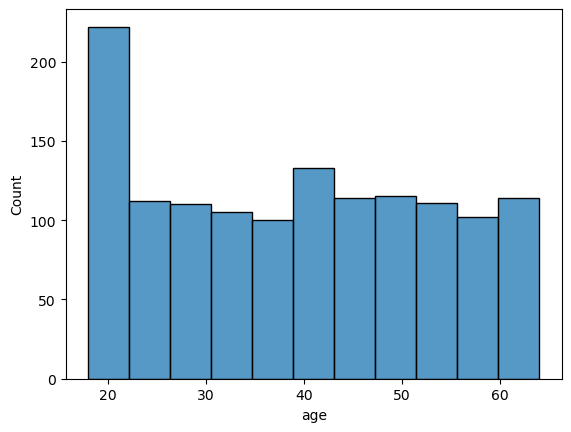

In [67]:
#check distributions of each column
sns.histplot(df, x='age',bins='fd')
plt.show()

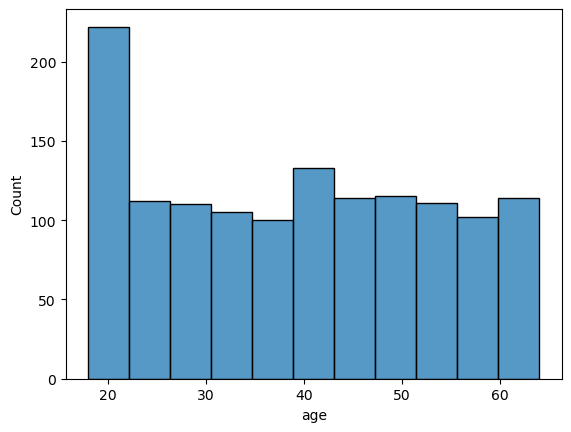

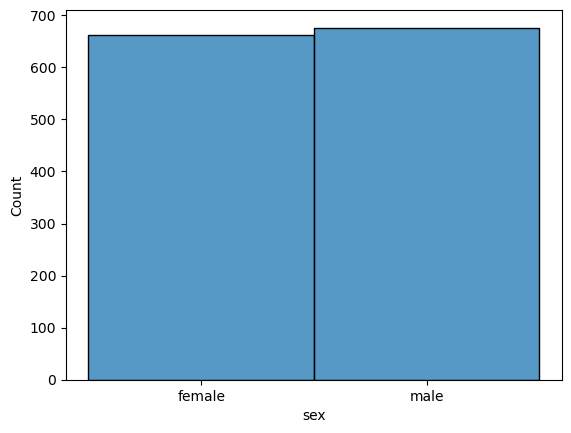

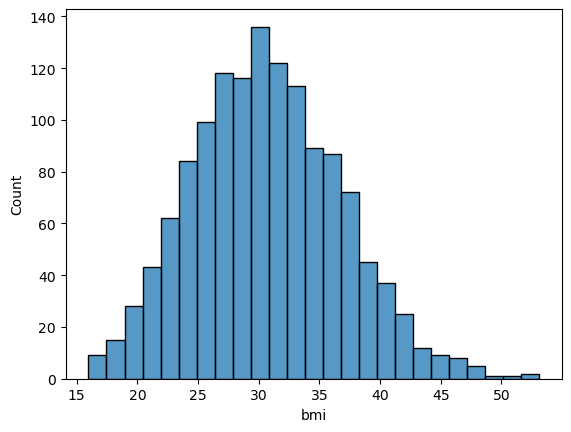

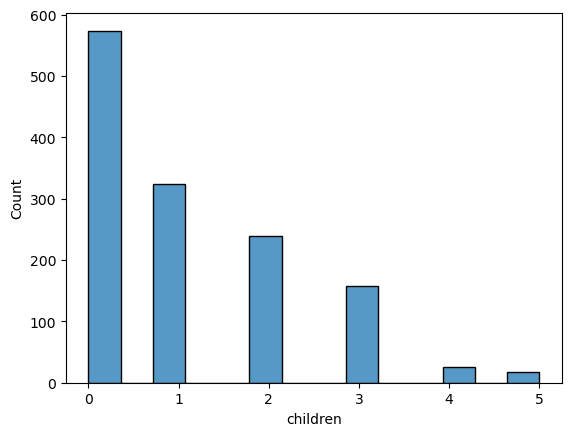

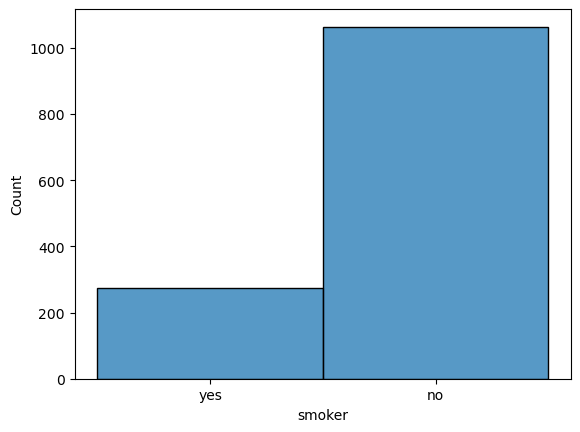

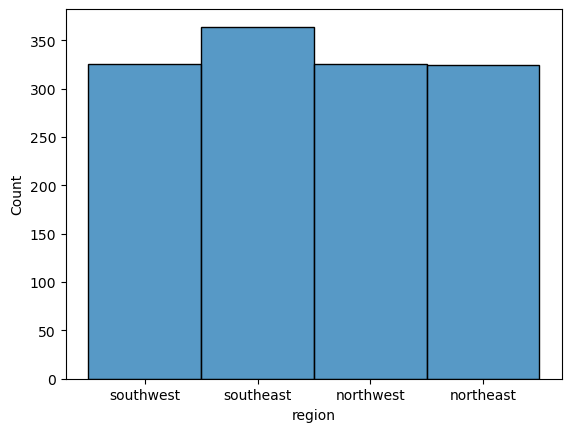

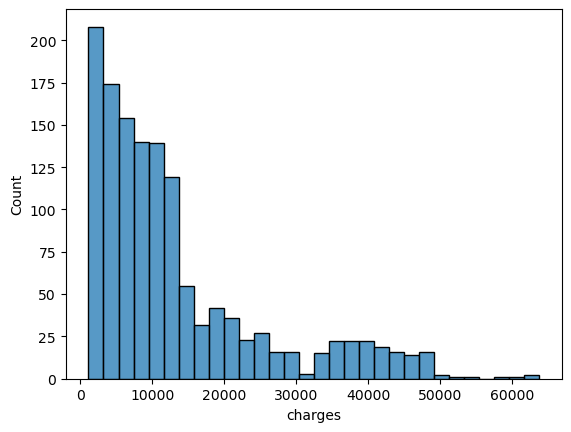

In [ ]:
# #check distributions of each column
# for col in df.columns:

#     sns.histplot(df, x=col,bins='fd')
#     plt.show()

#works well but not for all the columns like sex, smoker, region & children

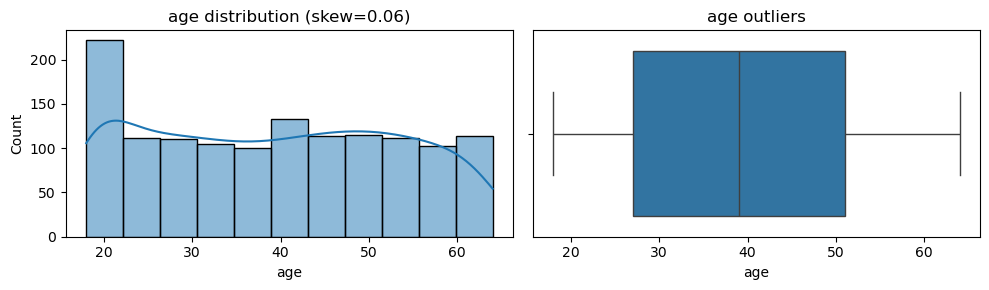

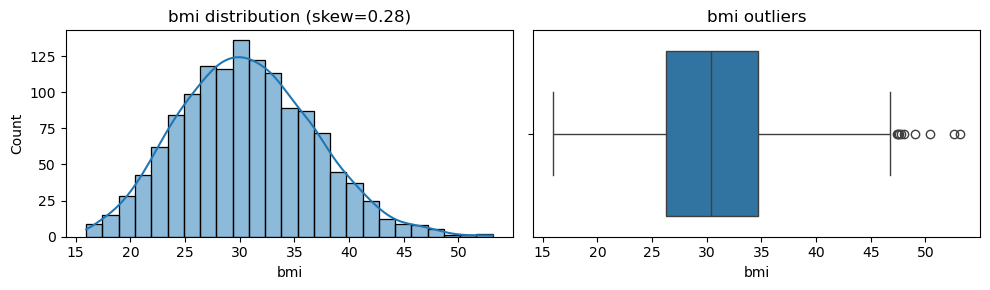

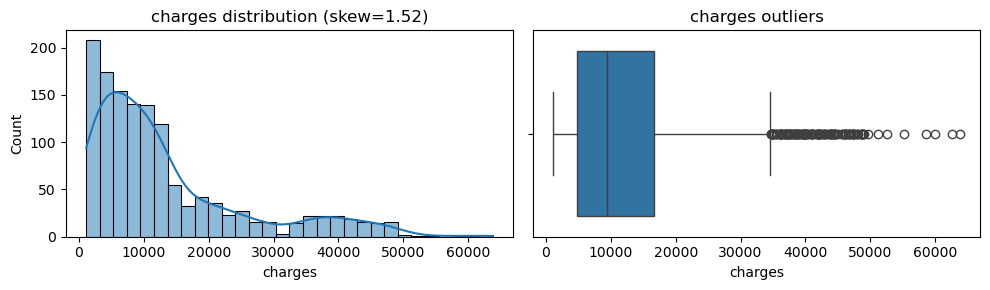

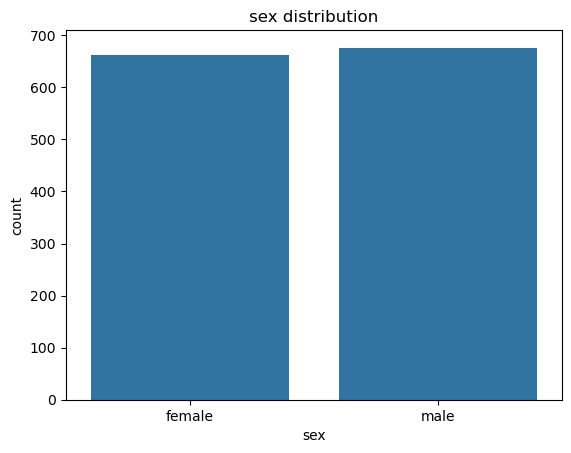

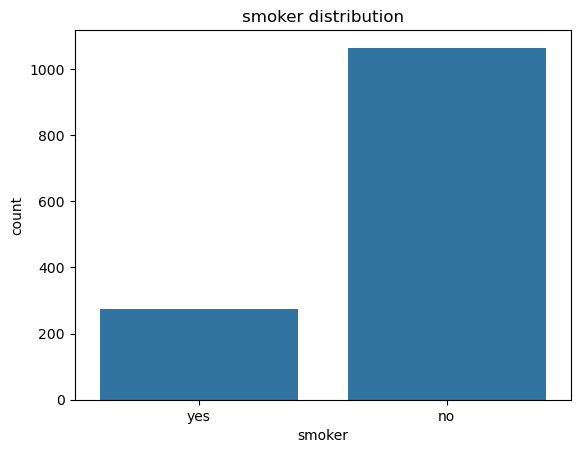

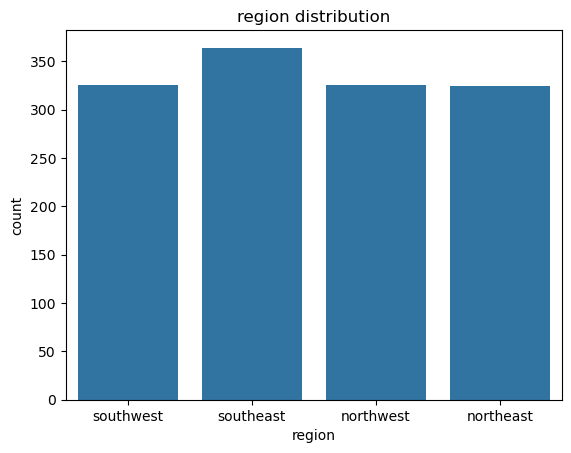

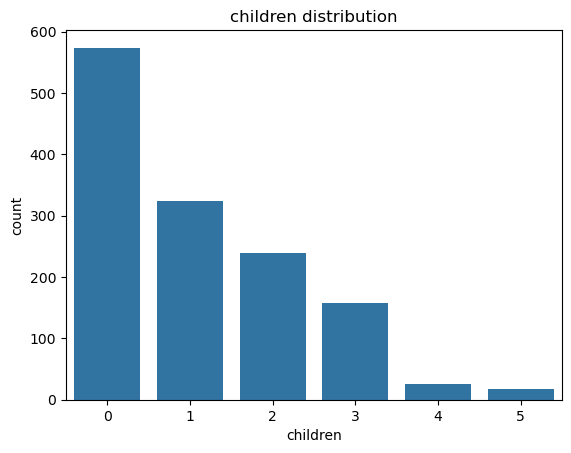

In [70]:
num_cols = ['age', 'bmi', 'charges']
cat_cols = ['sex', 'smoker', 'region', 'children']

#numeric: histograms + skew
for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df, x=col, bins='fd', kde=True, ax=ax[0])
    ax[0].set_title(f'{col} distribution (skew={df[col].skew():.2f})')
    sns.boxplot(df, x=col, ax=ax[1])
    ax[1].set_title(f'{col} outliers')
    plt.tight_layout()
    plt.show()

#categorical: counts
for col in cat_cols:
    sns.countplot(df, x=col)
    plt.title(f'{col} distribution')
    plt.show()

Seems most of the columns are not normally distributed. A special note on the `smoker` column that is skewed.


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
## bivariate analysis
""" 
- bmi & age
- smoker & region
- charges & children
- charges, region

--- sex, charges 
--- age, charges
--- bmi, charges
--- smorker, charges

<multivariate>
- bmi, age, sex
- charges, region, smoker

--- bmi, smoker, charges
"""